In [1]:
from __future__ import annotations
from dataclasses import dataclass
from typing import Optional, Tuple
import matplotlib.pyplot as plt
import numpy as np
import i24_motion_macro
import i24_motion_data
import optuna

In [ ]:
@dataclass
class TriangularFD:
    """
    Triangular fundamental diagram (per lane):
      - free-flow branch: q = v_f * rho
      - congested branch: q = w * (rho_j - rho)
    Units (SI recommended):
      rho: veh/m
      q:   veh/s
      v_f: m/s
      w:   m/s  (positive magnitude of backward wave speed)
      rho_j: veh/m
    """
    v_f: float    # free-flow speed (m/s)
    w: float      # congestion wave speed magnitude (m/s), positive
    rho_j: float  # jam density (veh/m)

    """
    @property
    def rho_c(self) -> float:
        # critical density where v_f * rho = w * (rho_j - rho)
        return (self.w / (self.v_f + self.w)) * self.rho_j
    """

    @staticmethod
    def flow(rho, v_f, w, rho_j):
        return v_f*rho*(1.0 - (rho/rho_j))

    @property
    def rho_c(self) -> float:
        return self.rho_j / 2.0

    @property
    def q_max(self) -> float:
        return self.flow(self.rho_c, self.v_f, self.w, self.rho_j)
    
    def demand(self, rho: np.ndarray) -> np.ndarray:
        '''D(rho): sending flow from an upstream cell.'''
        #print("Demand: ")
        #print(rho)
        rho = np.clip(rho, 0.0, self.rho_j)
        rho = np.minimum(rho, self.rho_c)
        #print(rho)
        flow = self.flow(rho, self.v_f, self.w, self.rho_j)
        #print(flow)
        return flow

    def supply(self, rho: np.ndarray) -> np.ndarray:
        '''S(rho): receiving flow into a downstream cell'''
        #print("Supply: ")
        #print(rho)
        rho = np.clip(rho, 0.0, self.rho_j)
        rho = np.maximum(rho, self.rho_c)
        #print(rho)
        flow = self.flow(rho, self.v_f, self.w, self.rho_j)
        #print(flow)
        return flow

    """
    def demand(self, rho: np.ndarray) -> np.ndarray:
        '''D(rho): sending flow from an upstream cell.'''
        rho = np.clip(rho, 0.0, self.rho_j)
        return np.minimum(self.v_f * rho, self.q_max)


    def supply(self, rho: np.ndarray) -> np.ndarray:
        '''S(rho): receiving flow into a downstream cell'''
        rho = np.clip(rho, 0.0, self.rho_j)
        return np.minimum(self.w * (self.rho_j - rho), self.q_max)
    """


@dataclass
class CTMConfig:
    dx: float  # cell length (m)
    dt: float  # time step (s)
    lanes: int

    def check_cfl(self, fd: TriangularFD) -> None:
        # CTM/Godunov stability: dt <= dx / max(v_f, w)
        vmax = max(fd.v_f, fd.w)
        if self.dt > self.dx / vmax + 1e-12:
            raise ValueError(
                f"CFL violated: dt={self.dt} > dx/max(v_f,w)={self.dx/vmax:.6f}"
            )


class CTMSolver:
    """
    Multi-lane CTM solver (lanes are independent here).
    rho shape: (lanes, n_cells)

    Coupling:
      - You can specify measured boundary flows (veh/s per lane):
          q_left[l]  : flow entering cell 0 from left boundary
          q_right[l] : flow leaving last cell to right boundary
        If not provided, solver uses "open boundary" by default:
          q_left  = demand(virtual upstream density) limited by supply(cell0)
          q_right = demand(lastcell) limited by supply(virtual downstream density)
        But for micro–macro coupling, you typically provide q_left/q_right
        from spawn/despawn counters (or metering gate logic).
    """
    def __init__(self, rho_init: np.ndarray, fd: TriangularFD, cfg: CTMConfig):
        if rho_init.ndim != 2:
            raise ValueError("rho_init must be 2D: (lanes, n_cells)")
        if rho_init.shape[0] != cfg.lanes:
            raise ValueError("rho_init lanes mismatch")
        self.rho = rho_init.astype(np.float64, copy=True)
        self.fd = fd
        self.cfg = cfg
        self.cfg.check_cfl(fd)

    @property
    def lanes(self) -> int:
        return self.cfg.lanes

    @property
    def n_cells(self) -> int:
        return self.rho.shape[1]

    def step(
        self,
        q_left: Optional[np.ndarray] = None,
        q_right: Optional[np.ndarray] = None,
        rho_upstream: Optional[np.ndarray] = None,
        rho_downstream: Optional[np.ndarray] = None,
    ) -> Tuple[np.ndarray, np.ndarray]:
        """
        Advance one CTM step.

        Inputs:
          q_left:  shape (lanes,) measured inflow into cell 0 (veh/s)
          q_right: shape (lanes,) measured outflow from last cell (veh/s)

          If q_left is None, you can provide rho_upstream (lanes,) as a "ghost density"
          to compute a Godunov boundary flux. Same for q_right with rho_downstream.

        Returns:
          (F, rho_new)
          F: interface fluxes shape (lanes, n_cells+1) where:
             F[:,0]       = left boundary inflow into cell 0
             F[:,i+1]     = flux from cell i -> i+1 (for i=0..n_cells-2)
             F[:,-1]      = right boundary outflow from last cell
        """
        L, N = self.rho.shape
        dx, dt = self.cfg.dx, self.cfg.dt

        rho = np.clip(self.rho, 0.0, self.fd.rho_j)

        # Compute interior demands/supplies
        D = self.fd.demand(rho)   # (L,N)
        S = self.fd.supply(rho)   # (L,N)

        # Flux array: interfaces 0..N (N+1 interfaces)
        F = np.zeros((L, N + 1), dtype=np.float64)

        # --- Left boundary flux F[:,0] ---
        if q_left is not None:
            q_left = np.asarray(q_left, dtype=np.float64)
            if q_left.shape != (L,):
                raise ValueError("q_left must have shape (lanes,)")
            # Can't exceed receiving capacity of cell 0
            F[:, 0] = np.clip(q_left, 0.0, S[:, 0])
        else:
            # Godunov/open boundary using upstream ghost density
            if rho_upstream is None:
                # default: "infinite demand" upstream (i.e., inject up to supply)
                D_up = np.full((L,), self.fd.q_max, dtype=np.float64)
            else:
                rho_upstream = np.asarray(rho_upstream, dtype=np.float64)
                if rho_upstream.shape != (L,):
                    raise ValueError("rho_upstream must have shape (lanes,)")
                D_up = self.fd.demand(rho_upstream)
            F[:, 0] = np.minimum(D_up, S[:, 0])

        # --- Interior fluxes F[:,1..N-1] (cell i -> i+1) ---
        for i in range(N - 1):
            F[:, i + 1] = np.minimum(D[:, i], S[:, i + 1])

        # --- Right boundary flux F[:,-1] ---
        if q_right is not None:
            q_right = np.asarray(q_right, dtype=np.float64)
            if q_right.shape != (L,):
                raise ValueError("q_right must have shape (lanes,)")
            # Can't exceed sending capacity of last cell
            F[:, -1] = np.clip(q_right, 0.0, D[:, -1])
        else:
            # Godunov/open boundary using downstream ghost density
            if rho_downstream is None:
                # default: "infinite supply" downstream (i.e., accept up to demand)
                S_dn = np.full((L,), self.fd.q_max, dtype=np.float64)
            else:
                rho_downstream = np.asarray(rho_downstream, dtype=np.float64)
                if rho_downstream.shape != (L,):
                    raise ValueError("rho_downstream must have shape (lanes,)")
                S_dn = self.fd.supply(rho_downstream)
            F[:, -1] = np.minimum(D[:, -1], S_dn)

        # --- Update densities by conservation ---
        # rho_i^{n+1} = rho_i^n - (dt/dx)(F_{i+1/2} - F_{i-1/2})
        rho_new = rho - (dt / dx) * (F[:, 1:] - F[:, :-1])

        # physical bounds
        rho_new = np.clip(rho_new, 0.0, self.fd.rho_j)

        self.rho = rho_new
        return F, rho_new

    def derived_flow_and_speed(self) -> Tuple[np.ndarray, np.ndarray]:
        """
        For diagnostics:
          q_cell = f(rho) (veh/s)
          v_cell = q_cell / rho (m/s), with safe handling of rho=0
        """
        rho = np.clip(self.rho, 0.0, self.fd.rho_j)
        q = np.minimum(self.fd.v_f * rho, self.fd.w * (self.fd.rho_j - rho))
        v = np.divide(q, np.maximum(rho, 1e-12))
        return q, v


# ---------------- Example usage ----------------

def sim_example():
    # 4 lanes, 200 cells, 20 m per cell = 4 km segment
    lanes = 4
    n_cells = 200
    dx = 20.0   # m
    dt = 0.5    # s

    # Typical-ish per-lane params
    fd = TriangularFD(
        v_f=33.0,        # 33 m/s ~ 74 mph
        w=5.0,           # 5 m/s ~ 11 mph backward wave speed magnitude
        rho_j=0.15       # 0.15 veh/m ~ 150 veh/km per lane
    )

    rho0 = np.zeros((lanes, n_cells))
    rho0[:] = 0.02  # 0.02 veh/m = 20 veh/km per lane (light/moderate)

    cfg = CTMConfig(dx=dx, dt=dt, lanes=lanes)
    ctm = CTMSolver(rho_init=rho0, fd=fd, cfg=cfg)

    # Suppose micro bubble sits between some indices, and you measure interface flows:
    # Here: just inject a constant inflow at left and throttle outflow at right (toy example).
    q_left_measured  = np.array([0.30, 0.30, 0.30, 0.30])  # veh/s per lane
    q_right_measured = np.array([0.10, 0.10, 0.10, 0.10])  # veh/s per lane (congested downstream)

    for k in range(20):  # 10 seconds
        F, rho = ctm.step(q_left=q_left_measured, q_right=q_right_measured)
        q_cell, v_cell = ctm.derived_flow_and_speed()

    print("rho (lane0, first 10 cells):", rho[0, :10])
    print("flow boundary left/right lane0:", F[0, 0], F[0, -1])

In [3]:
sim_example()

rho (lane0, first 10 cells): [0.00909091 0.00909091 0.00909091 0.00909091 0.00909091 0.00909091
 0.00909091 0.00909095 0.00909122 0.00909295]
flow boundary left/right lane0: 0.3 0.1


In [4]:
i24data = i24_motion_data.I24MotionData(2, 1669812350, 1669812350+3600, 0, 1600)
i24macro = i24_motion_macro.I24MotionMacro(i24data, 2, "road_2")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [5]:
i24macro_lane_data = i24macro.loadProcessedMacroData()

In [6]:
i24macro_queries = i24macro.computeEdieBoxQueries()

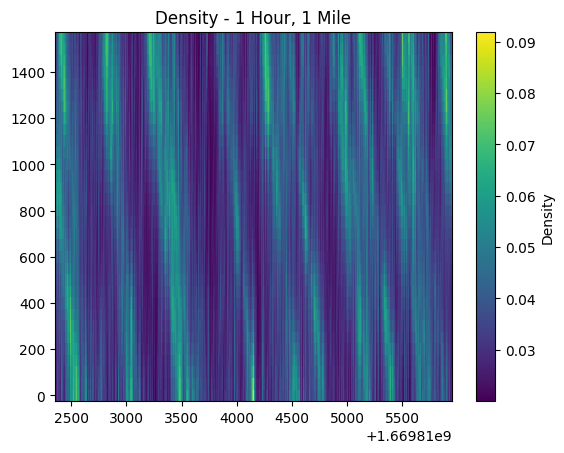

In [9]:
timestamp_min_display = np.array(i24macro_queries["timestamp_min"]).reshape((36000, 32)).T
s_min_display = np.array(i24macro_queries["s_min"]).reshape((36000, 32)).T
density_result_display = i24macro_lane_data[-1]["density"].reshape((36000, 32)).T
plt.pcolormesh(timestamp_min_display, s_min_display, density_result_display, cmap='viridis', shading='auto')
plt.title('Density - 1 Hour, 1 Mile')
plt.colorbar(label='Density')
plt.show()

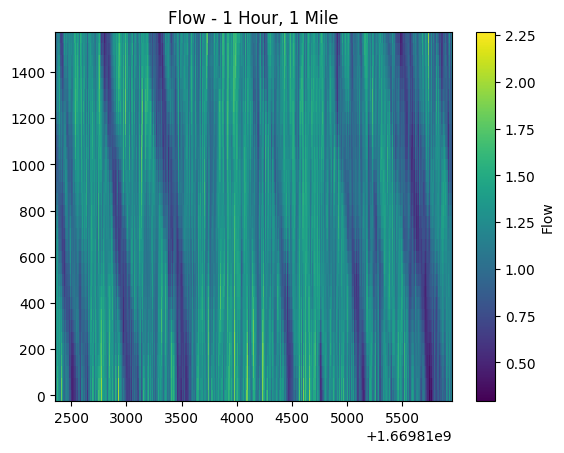

In [10]:
timestamp_min_display = np.array(i24macro_queries["timestamp_min"]).reshape((36000, 32)).T
s_min_display = np.array(i24macro_queries["s_min"]).reshape((36000, 32)).T
flow_result_display = i24macro_lane_data[-1]["flow"].reshape((36000, 32)).T
plt.pcolormesh(timestamp_min_display, s_min_display, flow_result_display, cmap='viridis', shading='auto')
plt.title('Flow - 1 Hour, 1 Mile')
plt.colorbar(label='Flow')
plt.show()

In [61]:
def sim_real_data(lane_data, lane_flow, dx = 50.0, dt = 0.1, v_f=33.0, rho_j=0.10):
    lane_data = lane_data.reshape((36000, 32))
    lane_flow = lane_flow.reshape((36000, 32))

    # 4 lanes, 200 cells, 20 m per cell = 4 km segment
    lanes = 1
    dx = dx
    dt = dt

    # Typical-ish per-lane params
    fd = TriangularFD(
        v_f=v_f,
        w=0.0,
        rho_j=rho_j
    )

    lane_data_source = lane_data[:, 1:-1].reshape((1, 36000, 30))
    lane_flow_source = lane_flow[:, 1:-1].reshape((1, 36000, 30))
    rho_left_measured = lane_data[:, 0].reshape((1, 36000, 1))
    rho_right_measured = lane_data[:, -1].reshape((1, 36000, 1))

    cfg = CTMConfig(dx=dx, dt=dt, lanes=lanes)
    ctm = CTMSolver(rho_init=lane_data_source[:, 0, :], fd=fd, cfg=cfg)

    result_density = np.zeros((36000, 30))
    result_density[0, :] = lane_data_source[0, 0, :]
    result_flow = np.zeros((36000, 30))
    result_flow[0, :] = lane_flow_source[0, 0, :]
    for k in range(36000 - 1):  # 1 hour
        F, rho = ctm.step(rho_upstream=rho_left_measured[:, k, 0], rho_downstream=rho_right_measured[:, k, 0])
        result_density[k+1, :] = rho
        result_flow[k + 1, :] = F[:, 1:]
        #result[k+1, 0] = rho_left_measured[:, k, 0]
        #result[k+1, -1] = rho_right_measured[:, k, 0]
        #q_cell, v_cell = ctm.derived_flow_and_speed()
    return result_density, result_flow

In [25]:
source_density = i24macro_lane_data[-1]["density"]
source_flow = i24macro_lane_data[-1]["flow"]
sim_density, sim_flow = sim_real_data(source_density, source_flow)
sim_flow = sim_flow * 10

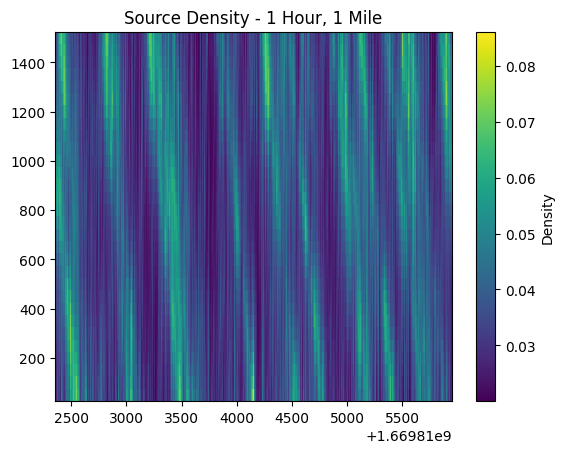

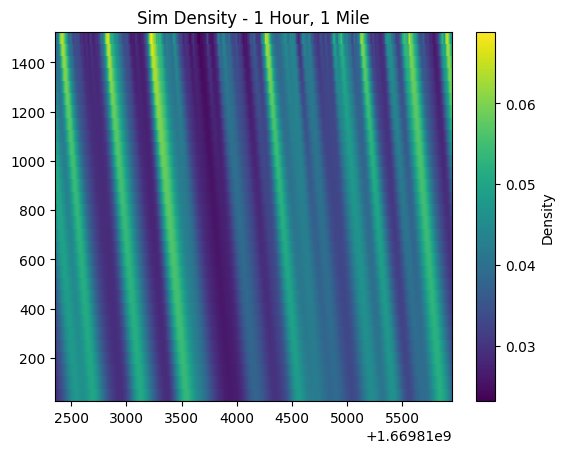

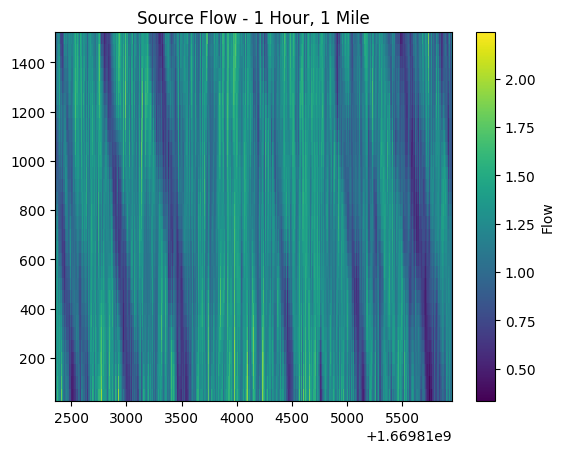

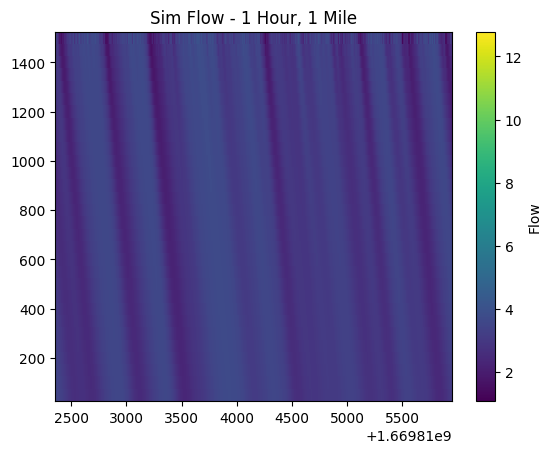

In [26]:
timestamp_min_display = np.array(i24macro_queries["timestamp_min"]).reshape((36000, 32))[:, 1:-1].T
s_min_display = np.array(i24macro_queries["s_min"]).reshape((36000, 32))[:, 1:-1].T
density_result_display = source_density.reshape((36000, 32))[:, 1:-1].T
plt.pcolormesh(timestamp_min_display, s_min_display, density_result_display, cmap='viridis', shading='auto')
plt.title('Source Density - 1 Hour, 1 Mile')
plt.colorbar(label='Density')
plt.show()

density_result_display = sim_density.reshape((36000, 30)).T
plt.pcolormesh(timestamp_min_display, s_min_display, density_result_display, cmap='viridis', shading='auto')
plt.title('Sim Density - 1 Hour, 1 Mile')
plt.colorbar(label='Density')
plt.show()

timestamp_min_display = np.array(i24macro_queries["timestamp_min"]).reshape((36000, 32))[:, 1:-1].T
s_min_display = np.array(i24macro_queries["s_min"]).reshape((36000, 32))[:, 1:-1].T
flow_result_display = source_flow.reshape((36000, 32))[:, 1:-1].T
plt.pcolormesh(timestamp_min_display, s_min_display, flow_result_display, cmap='viridis', shading='auto')
plt.title('Source Flow - 1 Hour, 1 Mile')
plt.colorbar(label='Flow')
plt.show()

flow_result_display = sim_flow.reshape((36000, 30)).T
plt.pcolormesh(timestamp_min_display, s_min_display, flow_result_display, cmap='viridis', shading='auto')
plt.title('Sim Flow - 1 Hour, 1 Mile')
plt.colorbar(label='Flow')
plt.show()

In [12]:
print(sim_density.min(), sim_density.mean(), sim_density.max(), sim_density.std())
print(source_density.min(), source_density.mean(), source_density.max(), source_density.std())
print(sim_flow.min(), sim_flow.mean(), sim_flow.max(), sim_flow.std())
print(source_flow.min(), source_flow.mean(), source_flow.max(), source_flow.std())

0.048112514257818186 0.05821636574643722 0.09473311699946999 0.0063356138534146
0.0424295593805276 0.06065685435083142 0.14054346033222115 0.010351167651673794
0.9474563030652084 1.4180894931187435 4.414382283527406 0.0683861125352725
0.2646379941986722 1.9091892570213305 4.722410521705994 0.5582629816710756


In [ ]:
def objective(trial):
    #v_f=33.0, w=5.0, rho_j=0.20
    v_f = trial.suggest_float('v_f', 10.0, 100.0)
    #w = trial.suggest_float('w', 4.5, 8.0)
    rho_j = trial.suggest_float('rho_j', 0.04, 0.15)
    source_density = i24macro_lane_data[-1]["density"]
    source_flow = i24macro_lane_data[-1]["flow"]
    sim_density, sim_flow = sim_real_data(source_density, source_flow, v_f=v_f, rho_j=rho_j)
    sim_flow = sim_flow
    density_mean_difference = (np.abs(sim_density - source_density[:, 1:-1])).mean()
    flow_mean_difference = (np.abs(sim_flow - source_flow[:, 1:-1])).mean()
    density_min_difference = abs(sim_density.min() - source_density.min())
    flow_min_difference = abs(sim_flow.min() - source_flow.min())
    density_max_difference = abs(sim_density.max() - source_density.max())
    flow_max_difference = abs(sim_flow.max() - source_flow.max())
    print(density_mean_difference, flow_mean_difference, density_min_difference, density_max_difference, flow_min_difference, flow_max_difference)
    return density_mean_difference + flow_mean_difference + density_min_difference + flow_min_difference + density_max_difference + flow_max_difference
    #return flow_mean_difference

study = optuna.create_study()
study.optimize(objective, n_trials=500)

study.best_params  # E.g. {'x': 2.002108042}

[I 2026-03-25 17:00:00,901] A new study created in memory with name: no-name-97a5f52a-4d4f-4065-820d-fe8406fcc7cb
[I 2026-03-25 17:00:02,249] Trial 0 finished with value: 0.009746431851623657 and parameters: {'v_f': 35.41546035684627, 'rho_j': 0.13228720799478536}. Best is trial 0 with value: 0.009746431851623657.


0.009746431851623657 0.28462294879885536 0.002089452926863921 0.029446711424675392 0.35899112136909817 0.9902081489562988


[I 2026-03-25 17:00:03,615] Trial 1 finished with value: 0.007064180906141757 and parameters: {'v_f': 45.3482913008067, 'rho_j': 0.05854810387338929}. Best is trial 1 with value: 0.007064180906141757.


0.007064180906141757 0.6340124389873364 0.006921441872478909 0.033405717606884947 0.2927968502044678 0.9902081489562988


[I 2026-03-25 17:00:04,975] Trial 2 finished with value: 0.008940658317676473 and parameters: {'v_f': 25.047528182848524, 'rho_j': 0.10823537242602202}. Best is trial 1 with value: 0.007064180906141757.


...

0.007245662606767689 0.5093346052841397 0.004551917056988444 0.03308743002191875 0.2927968502044678 0.9902081489562988


[I 2026-03-25 17:00:13,070] Trial 8 finished with value: 0.008794240589747619 and parameters: {'v_f': 29.435068224789454, 'rho_j': 0.10187130107818101}. Best is trial 1 with value: 0.007064180906141757.


0.008794240589747619 0.4847363295997929 0.002411124077437772 0.023585863114045147 0.22182887932117412 0.9902081489562988


[W 2026-03-25 17:00:14,163] Trial 9 failed with parameters: {'v_f': 65.1221880976114, 'rho_j': 0.12012546045668124} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "/home/richarwa/miniconda3/envs/i24macro/lib/python3.10/site-packages/optuna/study/_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
  File "/tmp/ipykernel_1498807/1719743552.py", line 8, in objective
    sim_density, sim_flow = sim_real_data(source_density, source_flow, v_f=v_f, rho_j=rho_j)
  File "/tmp/ipykernel_1498807/4159379238.py", line 30, in sim_real_data
    F, rho = ctm.step(rho_upstream=rho_left_measured[:, k, 0], rho_downstream=rho_right_measured[:, k, 0])
  File "/tmp/ipykernel_1498807/2517433427.py", line 178, in step
    F[:, i + 1] = np.minimum(D[:, i], S[:, i + 1])
KeyboardInterrupt
[W 2026-03-25 17:00:14,163] Trial 9 failed with value None.


KeyboardInterrupt: 

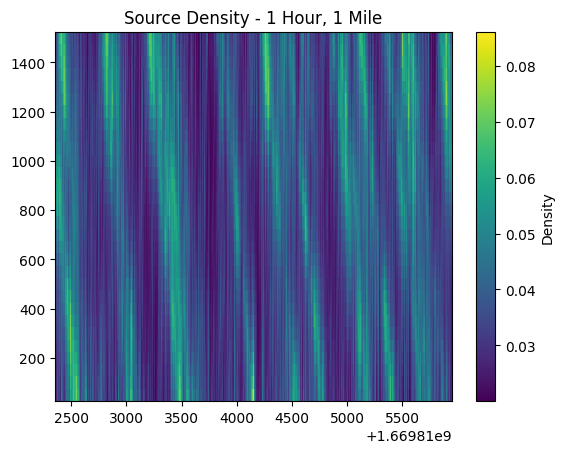

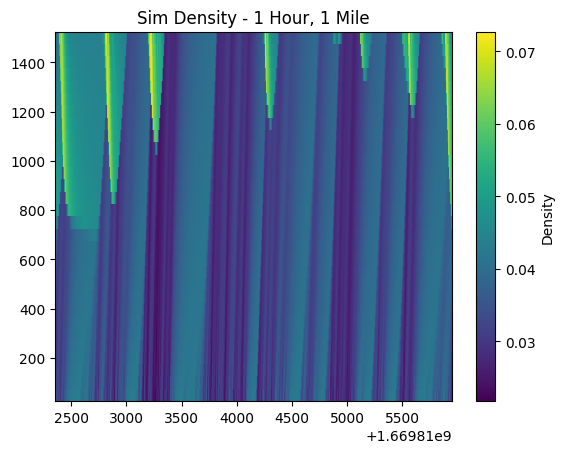

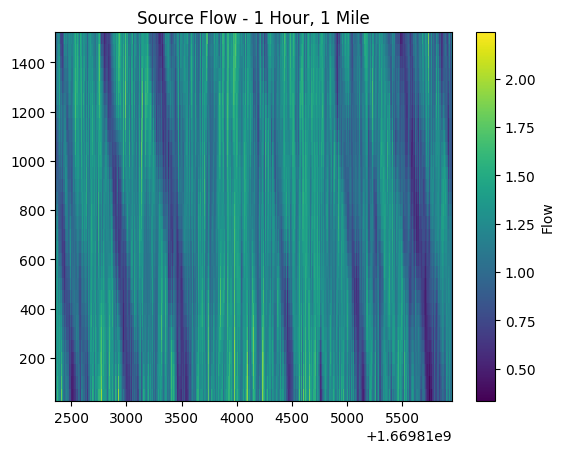

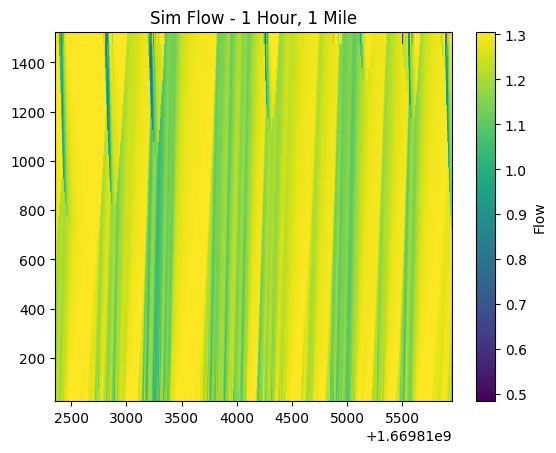

0.02172521059495448 0.036063006652017796 0.07275768480023798 0.007220611883649106
0.020004682 0.038042694 0.09195382 0.009757992
0.4839025038614153 1.2295792403634385 1.30638525 0.07166803923164144
0.29279685 1.151492 2.269082 0.23096663


In [83]:
source_density = i24macro_lane_data[-1]["density"]
source_flow = i24macro_lane_data[-1]["flow"]
sim_density, sim_flow = sim_real_data(source_density, source_flow, v_f=59.70, rho_j=0.08753)
sim_flow = sim_flow
timestamp_min_display = np.array(i24macro_queries["timestamp_min"]).reshape((36000, 32))[:, 1:-1].T
s_min_display = np.array(i24macro_queries["s_min"]).reshape((36000, 32))[:, 1:-1].T
density_result_display = source_density.reshape((36000, 32))[:, 1:-1].T
plt.pcolormesh(timestamp_min_display, s_min_display, density_result_display, cmap='viridis', shading='auto')
plt.title('Source Density - 1 Hour, 1 Mile')
plt.colorbar(label='Density')
plt.show()

density_result_display = sim_density.reshape((36000, 30)).T
plt.pcolormesh(timestamp_min_display, s_min_display, density_result_display, cmap='viridis', shading='auto')
plt.title('Sim Density - 1 Hour, 1 Mile')
plt.colorbar(label='Density')
plt.show()

timestamp_min_display = np.array(i24macro_queries["timestamp_min"]).reshape((36000, 32))[:, 1:-1].T
s_min_display = np.array(i24macro_queries["s_min"]).reshape((36000, 32))[:, 1:-1].T
flow_result_display = source_flow.reshape((36000, 32))[:, 1:-1].T
plt.pcolormesh(timestamp_min_display, s_min_display, flow_result_display, cmap='viridis', shading='auto')
plt.title('Source Flow - 1 Hour, 1 Mile')
plt.colorbar(label='Flow')
plt.show()

flow_result_display = sim_flow.reshape((36000, 30)).T
plt.pcolormesh(timestamp_min_display, s_min_display, flow_result_display, cmap='viridis', shading='auto')
plt.title('Sim Flow - 1 Hour, 1 Mile')
plt.colorbar(label='Flow')
plt.show()

print(sim_density.min(), sim_density.mean(), sim_density.max(), sim_density.std())
print(source_density.min(), source_density.mean(), source_density.max(), source_density.std())
print(sim_flow.min(), sim_flow.mean(), sim_flow.max(), sim_flow.std())
print(source_flow.min(), source_flow.mean(), source_flow.max(), source_flow.std())

In [78]:
TriangularFD.flow(np.array([0.1, 0.05, 0.04]), 40.0, 0.0, 0.1)

array([0.  , 1.  , 0.96])